In [87]:
#Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder

#To suppress all warnings
import warnings
warnings.filterwarnings('ignore')

In [88]:
path = "student-por.csv"
df1 = pd.read_csv(path, sep = ";")

In [89]:
df1.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [90]:
df1.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [91]:
df1.isna().sum()
# Checking for missing values.

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [92]:
df1.shape

(649, 33)

In [93]:
df1 = df1.drop_duplicates()

In [94]:
df1.shape # As we see, dataset has no duplicates, because the number of rows didnt change

(649, 33)

In [95]:
df1.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [96]:
df1.describe() # Basic statistic of numerical features in dataset(include outliers, mean values, etc.)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [97]:
df1.describe(include="O") # Basic statistic of categorical/binary features in dataset(include outliers, mean values, etc.)

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


## This dataset provides information about students who passed "Postuguese language" subject in two Portuguese schools. As we see, dataset has 33 columns and 649 rows. There is no missing values and duplicated rows in this dataset. We are predicting a G3(final grade of student) which is a target attribute.

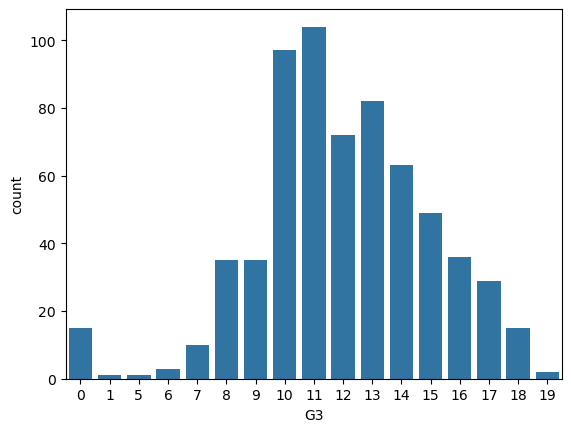

In [98]:
sns.countplot(x='G3', data=df1)
plt.show()

### Most student's final grade is between 10 and 15.

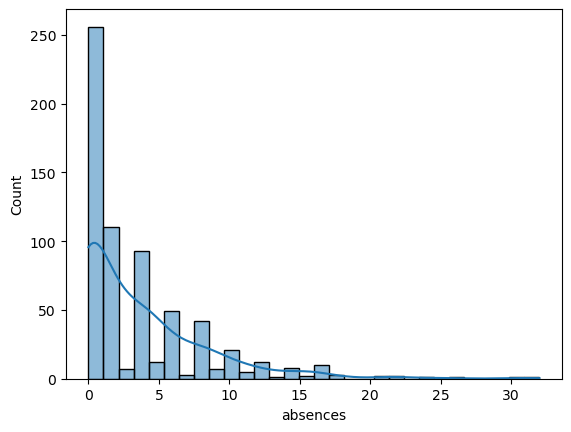

In [99]:
sns.histplot(df1["absences"], kde=True, bins=30)
plt.show()

### Most students have 0 absences.

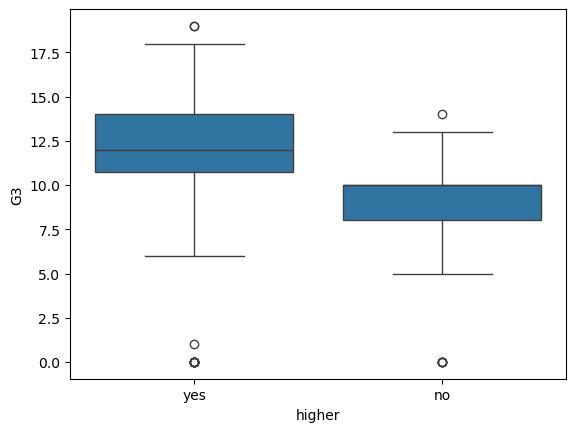

In [100]:
sns.boxplot(x='higher', y='G3', data=df1)
plt.show()

### Students who want to take higher education have better final grade in average. Hence, this feature is very important. Next plot proves it

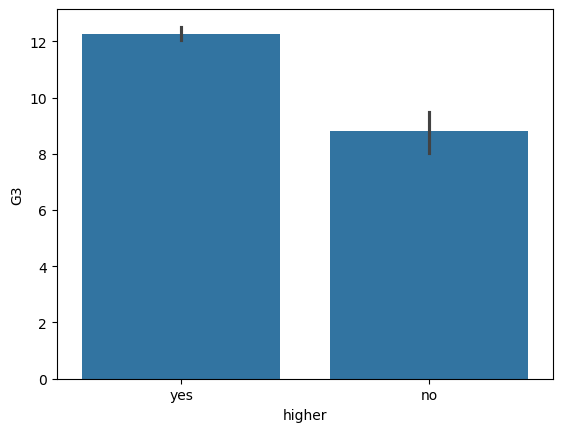

In [101]:
sns.barplot(x='higher', y="G3", data=df1)
plt.show()

### We can see significant difference of average final grade between students who DO want to take higher education and DONT

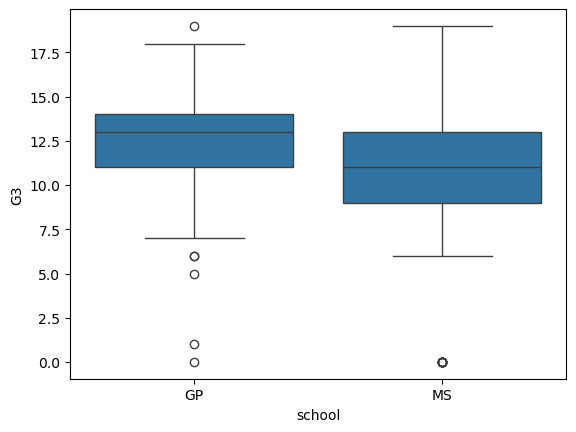

In [102]:
sns.boxplot(x='school', y='G3', data=df1)
plt.show()

### Gabriel Pereira (GP) students: Box shape is thiner. Hence, 50% of grades lies on small range.
### Mousinho da Silveira (MS) students: Box shape is thicker. Hence, 50% of grades lies on bigger range. However, lower than GP box
### We can conclude that, in average, Students from school of Gabriel Pereira (GP) have better final grade than students from Mousinho da Silveira (MS).

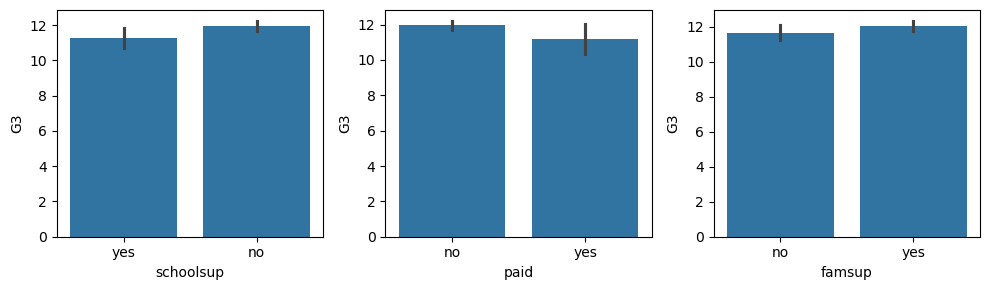

In [103]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
sns.barplot(x='schoolsup', y="G3", data=df1)

plt.subplot(1, 3, 2)
sns.barplot(x='paid', y="G3", data=df1)

plt.subplot(1, 3, 3)
sns.barplot(x='famsup', y="G3", data=df1)

plt.tight_layout()

plt.show()

### Our thoughts that school support, paid(extra classes) and family support are important for final grade became wrong.

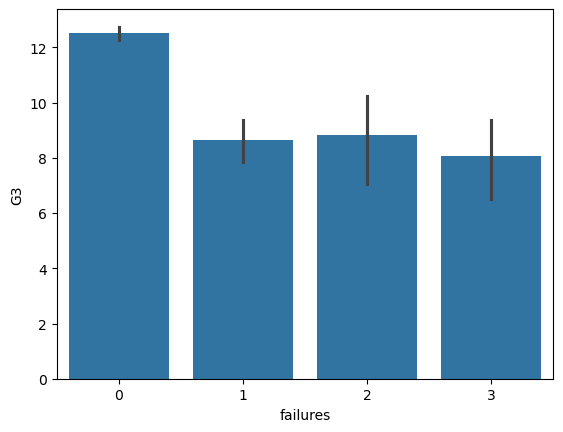

In [104]:
sns.barplot(x='failures', y="G3", data=df1)
plt.show()

### Students with zero failures have better average final grades

<Axes: >

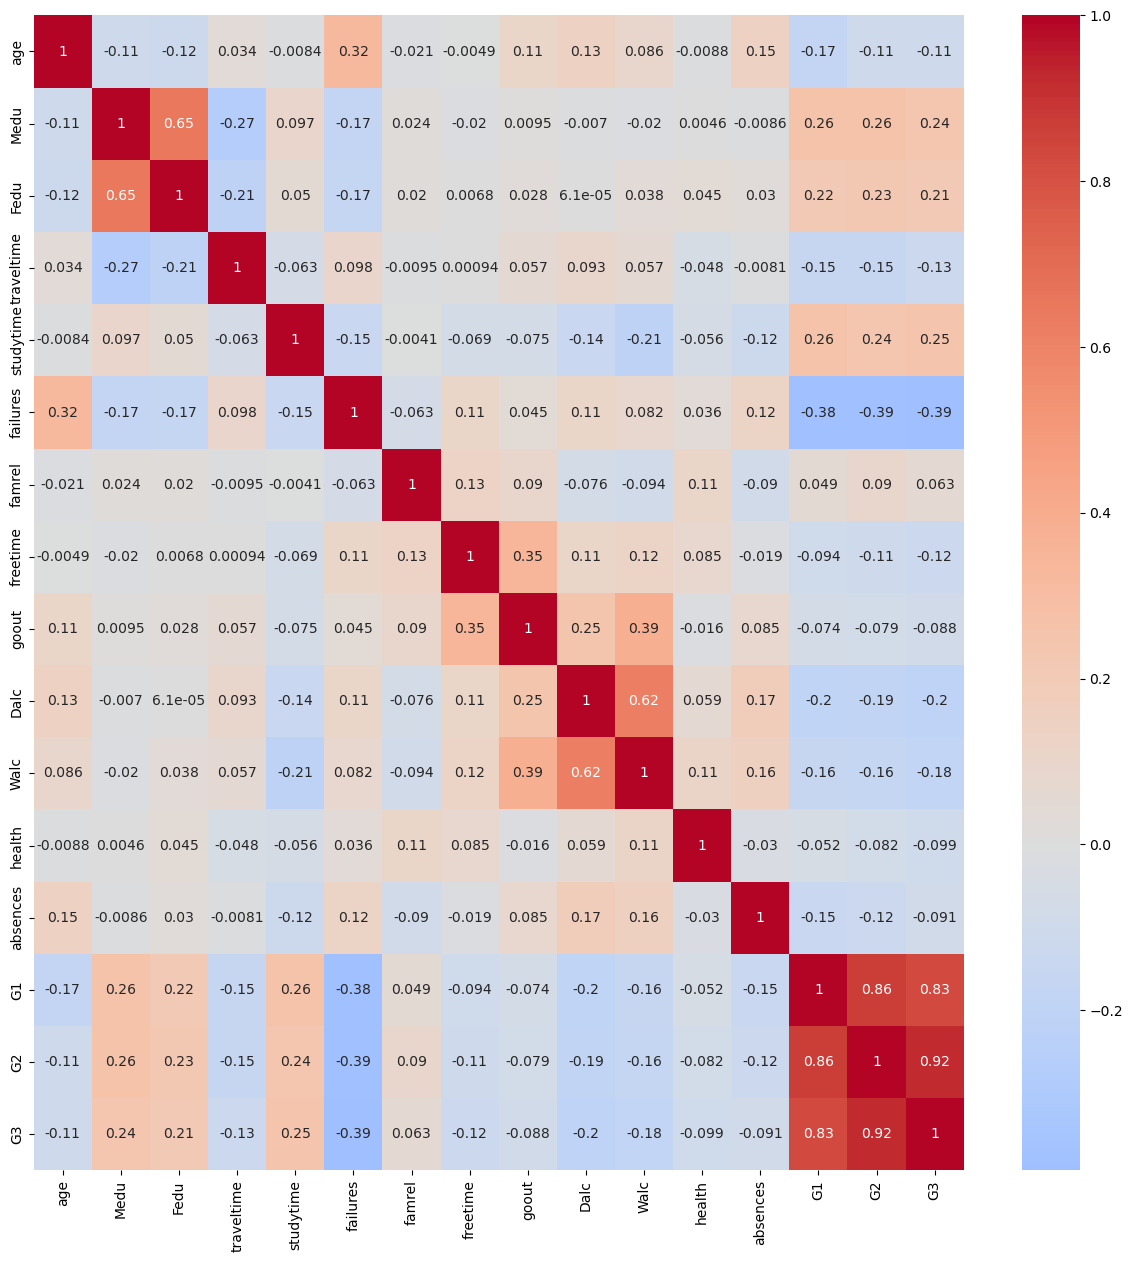

In [105]:
plt.figure(figsize=(15, 15))
sns.heatmap(df1.select_dtypes(include=["number"]).corr(), annot=True, cmap="coolwarm", center=0)

### The most significant features are G1 and G2(period grades). There is also strong positive correlation with Mother/Father education and studying time. In other hand, there is strong negative correlation with failures and alcohol consumption(Weekends/Weekdays). Both strong positive and negative correlations are useful for us

In [106]:
df1 = df1.drop(columns=["age", "famrel", "freetime", "goout", "health", "absences", "traveltime"])
# Dropping numerical columns with weak correlation

### We checked numerical features, now we should check categorical features for correlation with G3

In [107]:
# just compared label encoding and encoding by myself(just skip this part)
# Changing binary dtypes into numeric
# df3 = pd.DataFrame()
# df3["famsize_num"]=df1["famsize"].map({"LE3": 0, "GT3": 1})
# df3["Pstatus_num"]=df1["Pstatus"].map({"A": 0, "T": 1})
# df3["Mjob_num"]=df1["Mjob"].apply(lambda x: 0 if x=="at_home" else 1)
# df3["Fjob_num"]=df1["Fjob"].apply(lambda x: 0 if x=="at_home" else 1)
# df3["schoolsup_num"]=df1["schoolsup"].map({"no": 0, "yes": 1})
# df3["famsup_num"]=df1["famsup"].map({"no": 0, "yes": 1})
# df3["paid_num"]=df1["paid"].map({"no": 0, "yes": 1})
# df3["activities_num"]=df1["activities"].map({"no": 0, "yes": 1})
# df3["nursery_num"]=df1["nursery"].map({"no": 0, "yes": 1})
# df3["higher_num"]=df1["higher"].map({"no": 0, "yes": 1})
# df3["internet_num"]=df1["internet"].map({"no": 0, "yes": 1})
# df3["address_num"]=df1["address"].map({"R": 0, "U": 1})
# df3["school_num"]=df1["school"].map({"GP": 0, "MS": 1})
# df3["sex_num"]=df1["sex"].map({"F": 0, "M": 1})
# df3["reason_num"]=df1["reason"].apply(lambda x: 0 if x=="home" or x=="other" else 1)
# df3["guardian_num"]=df1["guardian"].apply(lambda x: 0 if x=="other" else 1)
# df3["romantic_num"]=df1["romantic"].map({"no": 0, "yes": 1})
# df3["G1"]=df1["G1"]
# df3["G2"]=df1["G2"]
# df3["G3"]=df1["G3"]

In [108]:
df3 = pd.DataFrame()
cols = df1.select_dtypes(include=['object']).columns
df3[cols] = df1[cols].apply(LabelEncoder().fit_transform) # Label Encoding to change categorical features into numerical
df3["G1"]=df1["G1"]
df3["G2"]=df1["G2"]
df3["G3"]=df1["G3"]

### Created another DataFrame df3 to select only categorical/binary columns and check correlation with final grade

<Axes: >

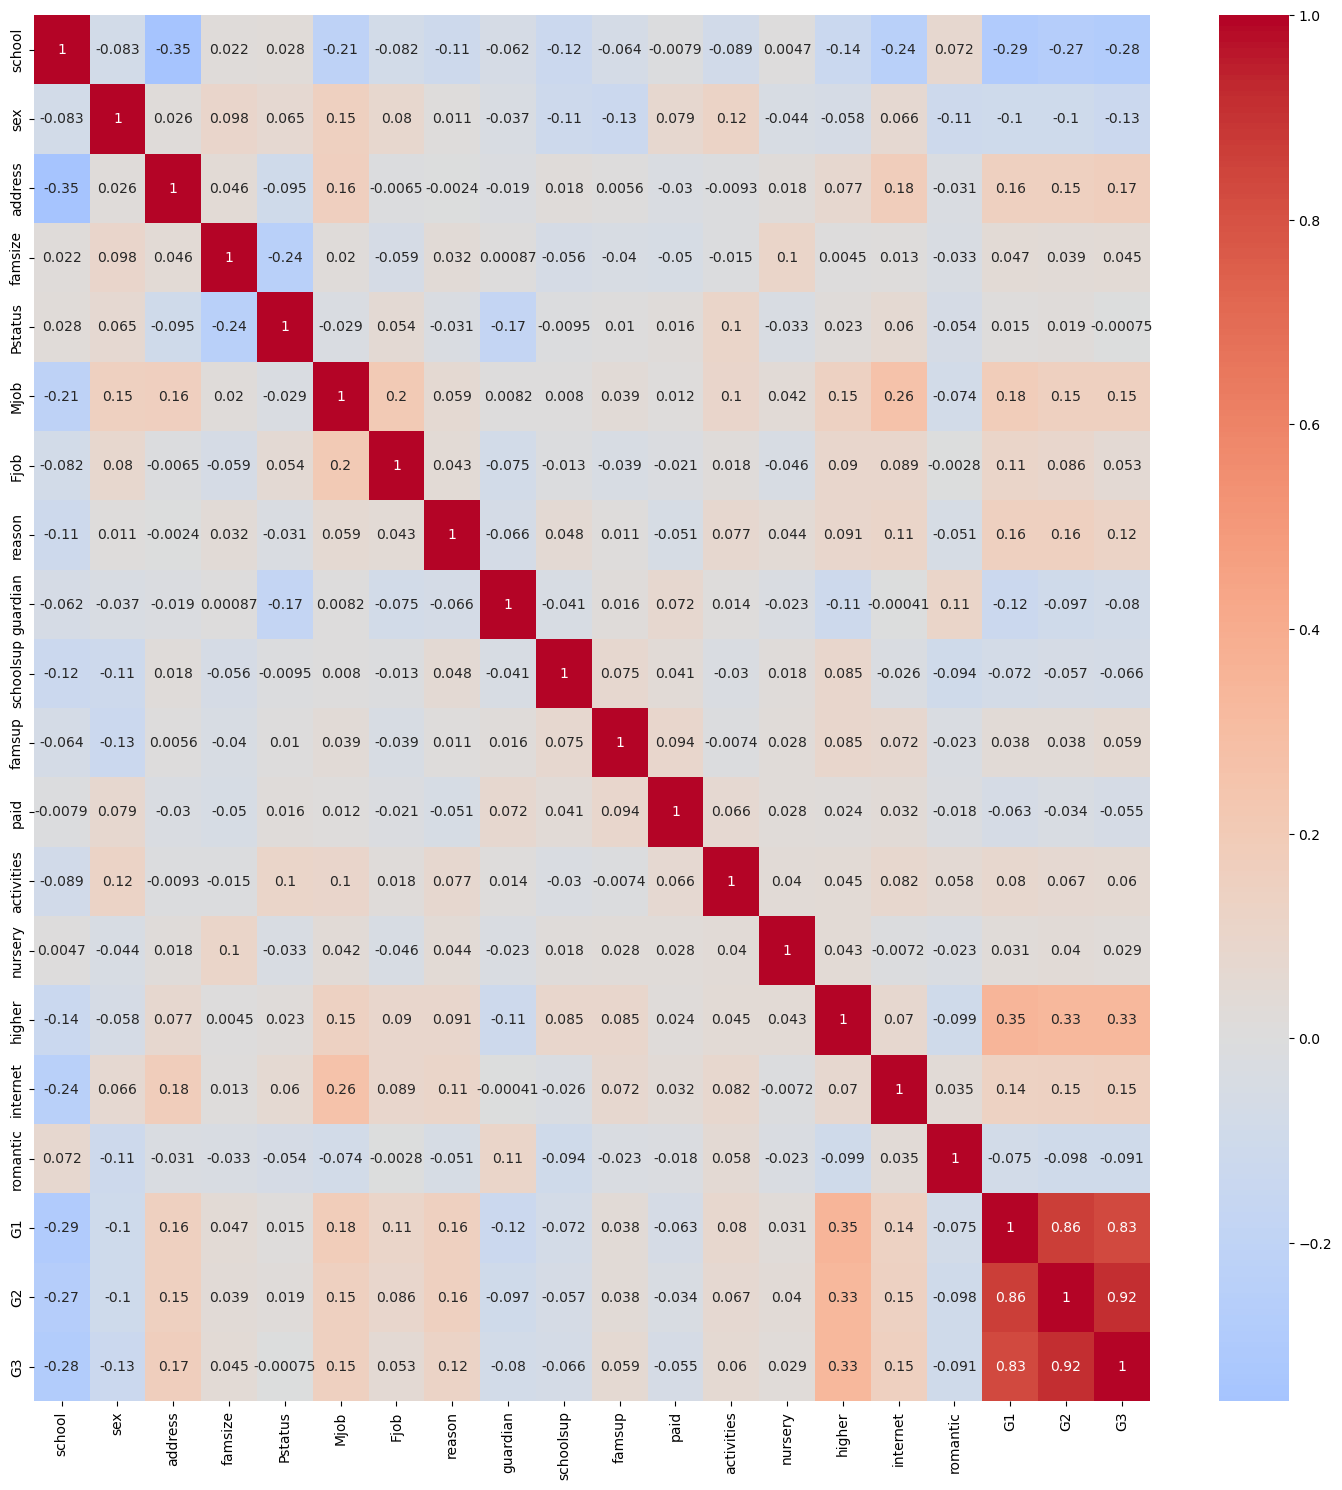

In [109]:
plt.figure(figsize=(18, 18))
sns.heatmap(df3.corr(), annot=True, cmap="coolwarm", center=0)

### Categorical features with strong correlation: school, address, higher. Our conclusions that we made before just have been prooved in this correlation map.(conclusions that students from "Gabriel Pereira" school and students who want to take higher education have better final grades)

In [110]:
df1 = df1.drop(columns=["famsize", "Pstatus", "Mjob", "Fjob", "schoolsup", "famsup", "paid", "activities", "nursery", "internet", "sex", "reason", "guardian", "romantic"])
# dropping categorical columns with weak correlation

In [111]:
cols = df1.select_dtypes(include=['object']).columns
df1[cols] = df1[cols].apply(LabelEncoder().fit_transform)
# Now we can do encoding on original DataFrame(also, a model cannot train on categorical data)

In [112]:
df1.shape

(649, 12)

In [113]:
df1.head() # So, now we have only 11 features 

,school,address,Medu,Fedu,studytime,failures,higher,Dalc,Walc,G1,G2,G3
0,0,1,4,4,2,0,1,1,1,0,11,11
1,0,1,1,1,2,0,1,1,1,9,11,11
2,0,1,1,1,2,0,1,2,3,12,13,12
3,0,1,4,2,3,0,1,1,1,14,14,14
4,0,1,3,3,2,0,1,1,2,11,13,13


In [114]:
df1["academic_history"]=(df1["failures"]>0).astype(int)
df1["motivated_student"]=((df1["failures"]==0) & (df1["studytime"]>2)).astype(int)
# Creating new features

<Axes: >

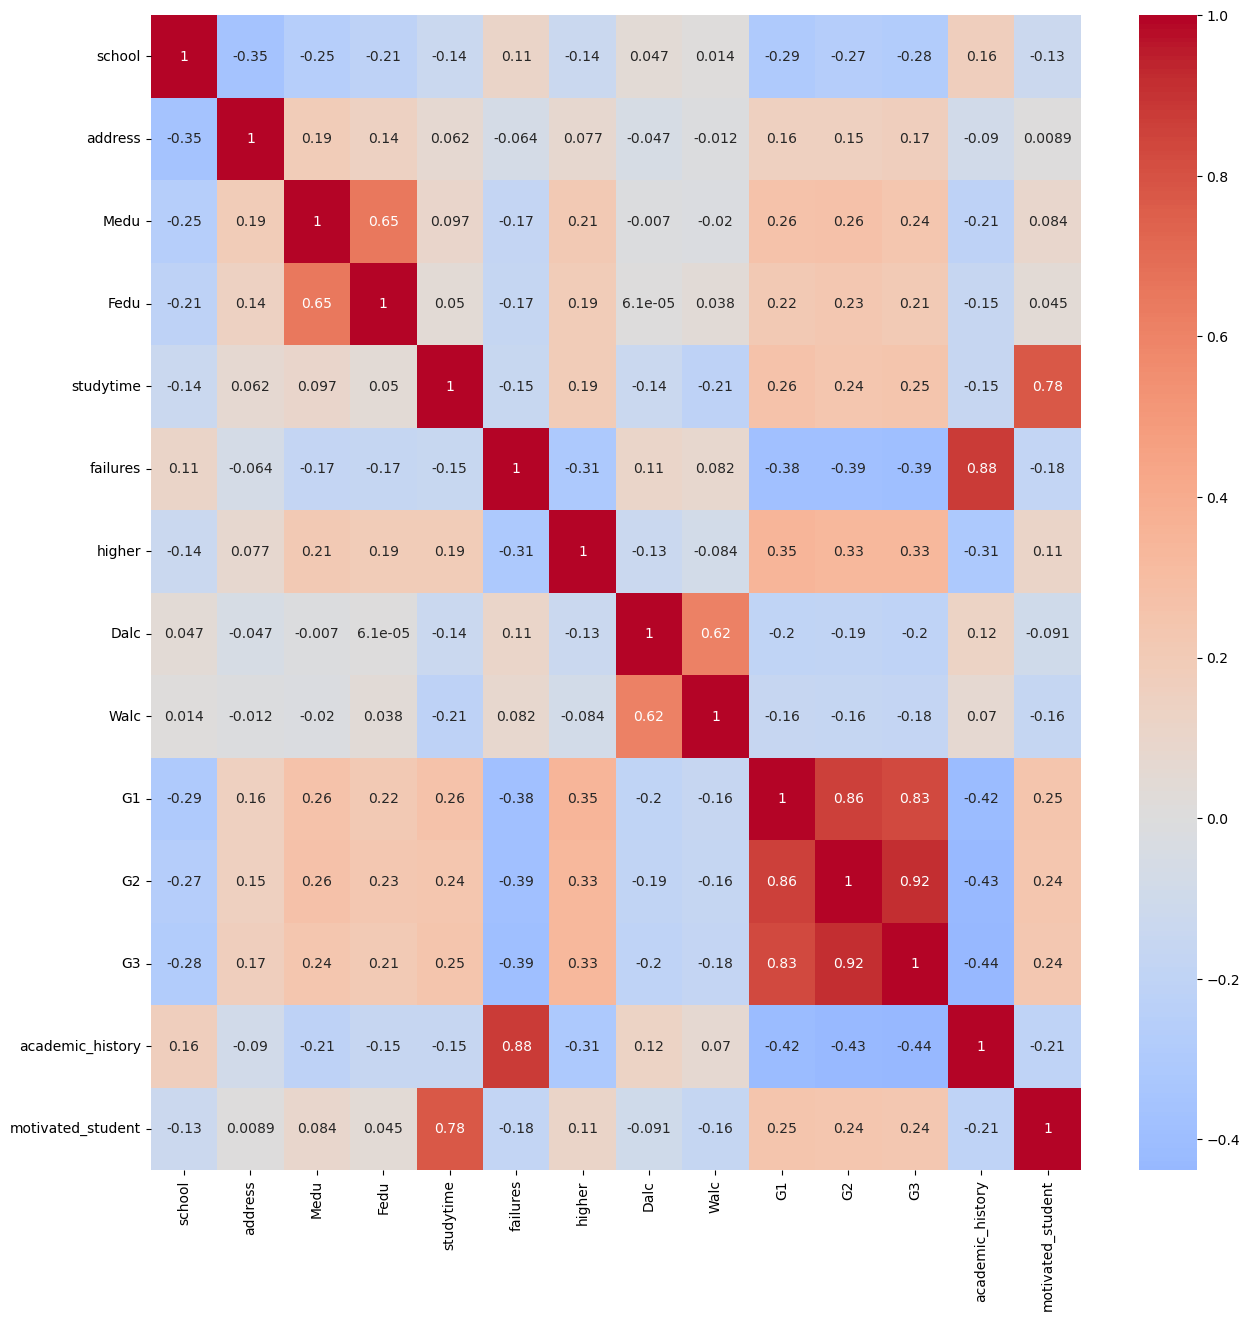

In [115]:
plt.figure(figsize=(15, 15))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm", center=0)

### So, now we have correlation map only with significant features

In [116]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

In [117]:
scaler = StandardScaler() # To make features standard normal distributed

In [118]:
X = df1[["school","address","Medu","Fedu","studytime","failures","higher","Dalc","Walc","academic_history","motivated_student","G1","G2"]]
y = df1["G3"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train) # To make features standard normal distributed
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(519, 13)
(130, 13)
(519,)
(130,)


<h1 align="center">Modelling Notebook</h1>

In [119]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 3 Models

In [120]:
models = {
    "Linear Regression (Base)": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=4),
    "Decision Tree": DecisionTreeRegressor(max_depth=3, random_state=42)
}

## Evaluation Metrics and Cross-Validation

In [121]:
result = []

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    # RMSE, MAE, R-squared metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Cross Validation
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    result.append({
        "Model": name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R-squared": round(r2, 4),
        "CV Mean (R2)": round(cv_score.mean(), 4),
        "CV Std (R2)": round(cv_score.std(), 4)
    })    

In [122]:
metrics_df = pd.DataFrame(result)
metrics_df

,Model,RMSE,MAE,R-squared,CV Mean (R2),CV Std (R2)
0,Linear Regression (Base),1.1846,0.7336,0.8561,0.8436,0.0467
1,KNN Regressor,1.5481,1.0942,0.7542,0.6501,0.0265
2,Decision Tree,1.3865,0.7861,0.8029,0.8166,0.0641


## Written Interpretation

`Linear Regression` emerged as the best-performing model for this dataset, achieving the highest **R-squared** (`0.8561`) and the lowest **error metrics** (RMSE: `1.1846`, MAE: `0.7336`).

**Why it performed best**: The target variable (**G3**) has a strong **linear relationship** with the features (**G1** and **G2**), which the `Linear Regression` captured efficiently without the risk of overfitting.

**Why other models less accurate?**: `KNN` and `Decision Trees` attempt to find local patterns or non-linear splits, which in this specific case led to slightly lower accuracy and higher sensitivity to noise.

The **Cross-Validation Mean** (`0.8436`) is very close to our test **R-squared**, and the low **Std** (`0.0467`) proves that the `Linear Regression` is stable and generalizes well across different subsets of data.

**Key Observations & Model Comparison**:

- **Overfitting vs. Stability**: The **`Decision Tree`** model exhibited a higher `CV Standard Deviation` (`0.0641`) compared to **`Linear Regression`** (`0.0467`). This indicates that the tree-based model is less stable and more prone to overfitting depending on how the data is split.

- **Error Analysis**: The fact that `RMSE` is notably higher than `MAE` across all models suggests that our dataset contains some outliers (students with unexpected final grades) that penalize the models more heavily.

- **Generalization**: The gap between the Test `R-squared` (`0.8561`) and the `Cross-Validation Mean` (`0.8436`) for `Linear Regression` is minimal, proving that the model generalizes well to unseen data.


## Progress Log

**What we tried**:

- We started by conducting thorough EDA in previous weeks to understand the correlations between socio-economic factors and student grades.

- For the modeling phase, we implemented a `Linear Regression` baseline and compared it with `KNN Regressor` and `Decision Tree Regressor`.

- We experimented with different hyperparameters, such as adjusting `n_neighbors` (from 3 to 10) for **`KNN`** and `max_depth` for the **`Decision Tree`** to find the optimal balance between bias and variance.

**What worked and what did not**:

- Worked: Applying StandardScaler to the encoded categorical and numerical features was crucial. It significantly improved the `KNN` model's performance, as it prevented features with larger scales from dominating the distance calculations.

- Did not work: Increasing the complexity of the **`Decision Tree`** (higher `max_depth`) led to immediate overfitting, where the training accuracy was high but the `Cross-Validation scores` dropped sharply. We decided to keep a shallow depth (3) for better stability.

**Blockers & Challenges**:

- One major blocker was the initial handling of categorical variables. We had to ensure that the LabelEncoder was applied consistently before scaling.

- We also faced a challenge in choosing the right metric for Cross-Validation. Initially, using `MSE` made it difficult to interpret stability, so we switched to `R-squared` for the `cross_val_score` to maintain consistency with our primary evaluation metric.